# Create intensity maps from data calibrated (interpolated)

### Inputs


In [1]:
#  Inputs

line_label = 'NeVIII' #'NeVIII', 'SiII', 'CIV', or 'cold_line'

save_intensity_map = 'yes' #save the array of intensity map as .npy

idx_spectral_image = 5 #Index of the spectral image that we will plot to show the range chosen

### Import libraries, functions...

In [2]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


import sys
import os
sys.path.append(os.path.abspath('..'))
from auxiliar_functions.SOHO_aux_functions import *
from auxiliar_functions.calibration_parameters__output import *
from auxiliar_functions.spectroheliogram_functions import *
from auxiliar_functions.solar_rotation_variables import *
from auxiliar_functions.aux_functions import *
from auxiliar_functions.general_variables import *
from auxiliar_functions.NeVIII_rest_wavelength import *

### Import SUMER data calibrated (interpolated)

In [3]:
# Import SUMER data interpolated (wavelength calibrated)
data_interpolated_loaded = np.load('../auxiliar_functions/wcal4__spectral_image_list_intepolated_and_wavelength.npz', allow_pickle=True)
spectral_image_interpolated_list = data_interpolated_loaded['spectral_image_interpolated_list']
spectral_image_unc_interpolated_list = data_interpolated_loaded['spectral_image_unc_interpolated_list']
lam_sumer = data_interpolated_loaded['reference_wavelength']          # [Angstrom] scalar (0‑d array; use a_loaded.item() for Python float)
elam_sumer = data_interpolated_loaded['unc_reference_wavelength'] #uncertainty of lam_sumer
row_reference = int(data_interpolated_loaded['row_reference'])        # [Angstrom] becomes a NumPy array or object array, so I conver it to integer again


### Select the variables corresponding to the line st the input

In [4]:
# Ranges of wavelength for the different lines

if line_label == 'NeVIII':
    wavelength_range_intensity_map = [1540.45, 1541.2] #Angstroem
    wavelength_range_intensity_map_bckg = [1539.8, 1540.2] #Angstroem
    line_center_label = 'Ne VIII - 770.428 \u212B'
    vmin_sumer, vmax_sumer = 8e-2, 1e1
    vmin_sumer_unc, vmax_sumer_unc = 1e-4, 4e-2
elif line_label == 'SiII':
    wavelength_range_intensity_map = [1533.170, 1533.645] #Angstroem
    #wavelength_range_intensity_map = [1533.17, 1533.725] #Angstroem
    wavelength_range_intensity_map_bckg = [1535.10, 1536.60] #Angstroem
    line_center_label = 'Si II - 1533.43 \u212B'
    vmin_sumer, vmax_sumer = 3e-2, 3e0
    vmin_sumer_unc, vmax_sumer_unc = 1e-4, 4e-2
elif line_label == 'CIV':
    wavelength_range_intensity_map = [1547.90, 1548.66] #Angstroem
    wavelength_range_intensity_map_bckg = [1545.93, 1547.65] #Angstroem
    line_center_label = 'C IV - 1548.21 \u212B'
    vmin_sumer, vmax_sumer = 8e-2, 1e1
    vmin_sumer_unc, vmax_sumer_unc = 1e-4, 4e-2
elif line_label == 'cold_line':
    wavelength_range_intensity_map = [1537.80, 1538.10] #Angstroem
    wavelength_range_intensity_map_bckg = [1538.30, 1538.39] #Angstroem
    line_center_label = 'Si I - 1537.94 \u212B'
    vmin_sumer, vmax_sumer = 8e-2, 1e1
    vmin_sumer_unc, vmax_sumer_unc = 1e-4, 4e-2


### Column indices of the wavelength range

In [5]:
pixelscale_reference = pixelscale_list[row_reference]
pixelscale_intercept_reference = pixelscale_intercept_list[row_reference]

w_cal_range_suggest = wavelength_range_intensity_map
w_cal_range_suggest_bckg = wavelength_range_intensity_map_bckg

# For the wavelength ranges in the input: find the pixel range and the exact wavelength range (from the center of the pixels of the range)
## Line to analyze:
w_px_range, w_cal_range_pixcenter = w_range_pixel_from_wavelength_calibrated_fullspectrum(w_cal_range=w_cal_range_suggest, slope_cal=pixelscale_reference, intercept_cal=pixelscale_intercept_reference)
## Background to subtract:
w_px_range_bckg, w_cal_range_pixcenter_bckg = w_range_pixel_from_wavelength_calibrated_fullspectrum(w_cal_range=w_cal_range_suggest_bckg, slope_cal=pixelscale_reference, intercept_cal=pixelscale_intercept_reference)


print('w_px_range:', w_px_range)
print('w_cal_range_suggest:', w_cal_range_suggest)
print('w_cal_range_pixcenter:', w_cal_range_pixcenter)
print('######################')
print('w_px_range_bckg:', w_px_range_bckg)
print('w_cal_range_suggest_bckg:', w_cal_range_suggest_bckg)
print('w_cal_range_pixcenter_bckg:', w_cal_range_pixcenter_bckg)

w_px_range: [238, 256]
w_cal_range_suggest: [1540.45, 1541.2]
w_cal_range_pixcenter: [1540.45322157, 1541.21062665]
######################
w_px_range_bckg: [222, 232]
w_cal_range_suggest_bckg: [1539.8, 1540.2]
w_cal_range_pixcenter_bckg: [1539.7799726100002, 1540.2007532100001]


### Show spectral image and profile

Here I show one of the 240 spectral images with vertical lines that mark the range for integration used for the intensity map (including the continuum). Also I show the averaged profile along the slit corresponding to this range. 

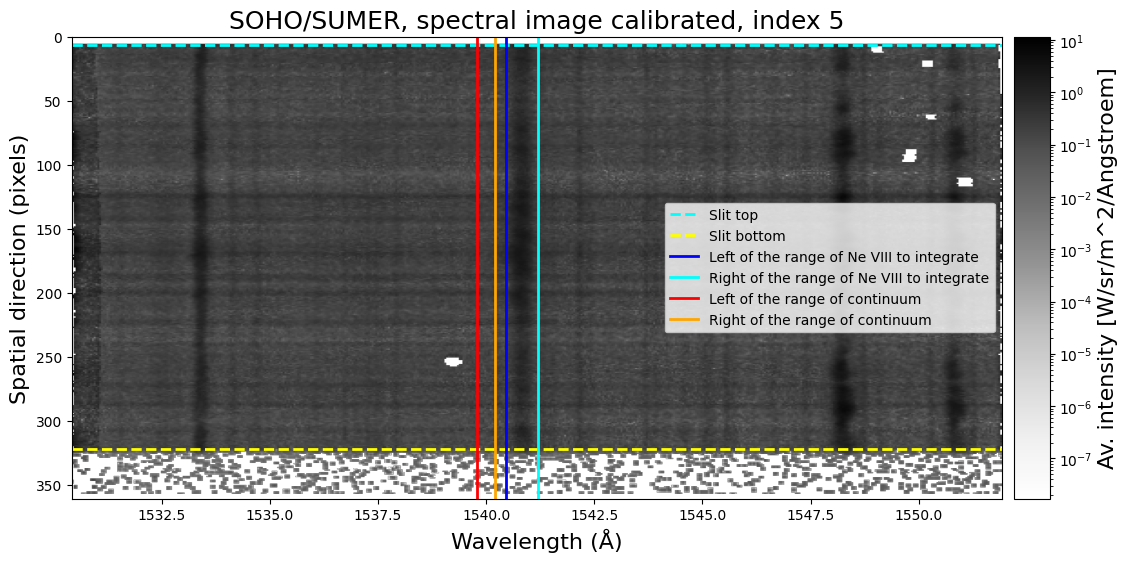

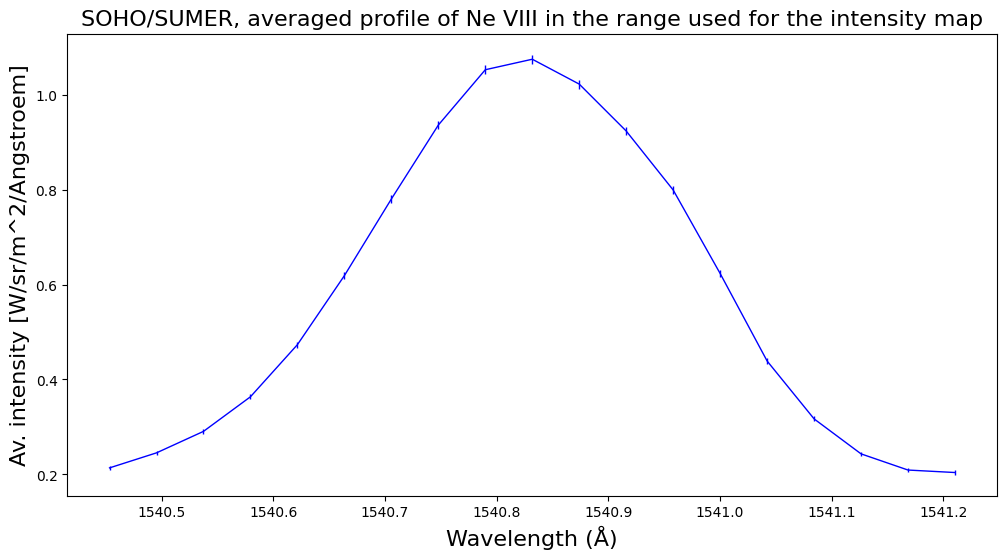

In [6]:
# Select one spectral image
spectral_image_interpolated = spectral_image_interpolated_list[idx_spectral_image]
spectral_image_unc_interpolated = spectral_image_unc_interpolated_list[idx_spectral_image]

# Crop spectral image in latitude
spectral_image_interpolated_crop = spectral_image_interpolated[slit_top_px:slit_bottom_px+1, w_px_range[0]:w_px_range[1]+1]
spectral_image_unc_interpolated_crop = spectral_image_unc_interpolated[slit_top_px:slit_bottom_px+1, w_px_range[0]:w_px_range[1]+1]



N_rows = 360

px_half = (lam_sumer[1] - lam_sumer[0])/2
extent = [lam_sumer[0]-px_half, lam_sumer[-1]-px_half, N_rows+0.5, 0-0.5]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_interpolated, cmap='Greys', aspect='auto', norm=LogNorm(), extent=extent)
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(f'Av. intensity [W/sr/m^2/Angstroem]', fontsize=16)
ax.set_title(f'SOHO/SUMER, spectral image calibrated, index {idx_spectral_image}', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.axhline(y=slit_top_px, linestyle='--', color='cyan', linewidth=2, label='Slit top')
ax.axhline(y=slit_bottom_px, linestyle='--', color='yellow', linewidth=2, label='Slit bottom')
ax.axvline(x=w_cal_range_pixcenter[0], linestyle='-', color='blue', linewidth=2, label='Left of the range of Ne VIII to integrate')
ax.axvline(x=w_cal_range_pixcenter[1], linestyle='-', color='cyan', linewidth=2, label='Right of the range of Ne VIII to integrate')
ax.axvline(x=w_cal_range_pixcenter_bckg[0], linestyle='-', color='red', linewidth=2, label='Left of the range of continuum')
ax.axvline(x=w_cal_range_pixcenter_bckg[1], linestyle='-', color='orange', linewidth=2, label='Right of the range of continuum')
ax.legend(fontsize=10)
plt.show(block=False)



x_profile = lam_sumer[w_px_range[0]:w_px_range[1]+1]
y_profile = spectral_image_interpolated_crop.mean(axis=0)
y_unc_profile = 1/(slit_bottom_px-slit_top_px+1) * np.sqrt((spectral_image_unc_interpolated_crop**2).sum(axis=0))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
ax.errorbar(x=x_profile, y=y_profile, yerr=y_unc_profile, color='blue', linewidth=1.)
ax.set_title(f'SOHO/SUMER, averaged profile of Ne VIII in the range used for the intensity map', fontsize=16) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. intensity [W/sr/m^2/Angstroem]', color='black', fontsize=16)
plt.show(block=False)

### Build the intensity map

I build the intensity map in this way:
1) Average the spectral radiance of the continuum: $C = \frac{1}{k}\sum_j^k C_j$.
2) I substract this averaged continuum ($C$) to the spectral radiance of the line: $I_i - C$
3) Integrate the previous result using the pixel width ($w$) in wavelength units: 

$$
I = w \sum^n_i (I_i-C)
$$

For the uncertainty I use error propagation:

$$
\Delta I^2 = \left( \frac{\partial I}{\partial w} \Delta w \right)^2 + \left( \frac{\partial I}{\partial I_1} \Delta I_1 \right)^2 + \left( \frac{\partial I}{\partial I_2} \Delta I_2 \right)^2 + \left( \frac{\partial I}{\partial I_3} \Delta I_3 \right)^2 + ... + \left( \frac{\partial I}{\partial C} \Delta C\right)^2
$$

$$
\Delta I^2 = \left( \frac{\partial I}{\partial w} \Delta w \right)^2 + \sum_i^n \left[ \left( \frac{\partial I}{\partial I_i} \Delta I_i \right)^2 \right] + \left( \frac{\partial I}{\partial C} \Delta C\right)^2
$$

where:

$$
\frac{\partial I}{\partial w} = \sum^n_i (I_i-C)
$$

$$
\frac{\partial I}{\partial I_i} = w
$$

$$
\frac{\partial I}{\partial C} = -n\cdot w \cdot C
$$

$$
\Delta C^2 = \left( \frac{\partial C}{\partial C_1} \Delta C_1 \right)^2 + \left( \frac{\partial C}{\partial C_2} \Delta C_2 \right)^2 + \left( \frac{\partial C}{\partial C_3} \Delta C_3 \right)^2 + ... = \sum_j^k \left( \frac{\partial C}{\partial C_j} \Delta C_j \right)^2 = \sum_j^k \left( \frac{\Delta C_j}{k}  \right)^2 = \frac{1}{k^2} \sum_j^k \Delta C_j^2 \rightarrow \Delta C = \frac{1}{k} \sqrt{\sum_j^k \Delta C_j^2}
$$

Then:

$$
\Delta I^2 = \left( \Delta w \cdot \sum^n_i (I_i-C) \right)^2 + \sum_i^n \left( w \cdot \Delta I_i \right)^2 + \left( -n\cdot w \cdot C \cdot \Delta C\right)^2
$$

In [7]:
# Create intensity map

def create_spectroheliogram_from_interpolation(spectralimage_interpolated_list, spectralimage_unc_interpolated_list, w_px_range, w_px_range_bckg, slope_list, slope_unc_list):
    c1, c2 = w_px_range
    n = c2 - c1 + 1
    cb1, cb2 = w_px_range_bckg
    k = cb2 - cb1 + 1
    
    spectroheliogram_line_NT, unc_spectroheliogram_line_NT  = [],[]
    for img_ in range(len(spectralimage_interpolated_list)):
        spectral_image_ = spectralimage_interpolated_list[img_]
        spectral_image_unc_ = spectralimage_unc_interpolated_list[img_]
        
        integrated_intensity_line_1col, unc_integrated_intensity_line_1col = [],[]
        for row_ in range(len(slope_list)): 

            # pixel scale
            w = slope_list[row_] 
            w_unc = slope_unc_list[row_] #uncertainty

            # Spectral radiance of the line
            I_i = spectral_image_[row_, c1:c2+1] #1d-array
            I_unc_i = spectral_image_unc_[row_, c1:c2+1] #1d-array (uncertainties)
            
            # Spectral radiance of the continuum
            C_j = spectral_image_[row_, cb1:cb2+1] #1d-array
            C_unc_j = spectral_image_unc_[row_, cb1:cb2+1] #1d-array (uncertainties)

            # Calculate the average of the profile of each row
            ## Average the continuum
            C = np.mean(C_j) 
            C_unc = (1/k) * np.sum(C_unc_j**2)
            ## Integrate the line
            I = w * np.sum(I_i - C) #continuum average
            I_unc_T1 = w_unc * np.sum(I_i - C)
            I_unc_T2 = np.sum((w*I_unc_i)**2)
            I_unc_T3 = n*w*C*C_unc
            I_unc = np.sqrt( I_unc_T1**2 + I_unc_T2**2 + I_unc_T3**2 )
            
            # Save in lists
            integrated_intensity_line_1col.append(I) 
            unc_integrated_intensity_line_1col.append(I_unc) 
        
        # save the above lists (which represent the columns) in lists to crate the 2D-array of the spectroheliogram
        spectroheliogram_line_NT.append(integrated_intensity_line_1col) 
        unc_spectroheliogram_line_NT.append(unc_integrated_intensity_line_1col)
        
    # Convert to array and transpose
    spectroheliogram_line = np.array(spectroheliogram_line_NT).T 
    unc_spectroheliogram_line = np.array(unc_spectroheliogram_line_NT).T
    
    return [spectroheliogram_line, unc_spectroheliogram_line]

In [8]:
intensity_map, intensity_map_unc = create_spectroheliogram_from_interpolation(spectralimage_interpolated_list=spectral_image_interpolated_list, spectralimage_unc_interpolated_list=spectral_image_unc_interpolated_list, w_px_range=w_px_range, w_px_range_bckg=w_px_range_bckg, slope_list=pixelscale_list, slope_unc_list=pixelscale_unc_list)


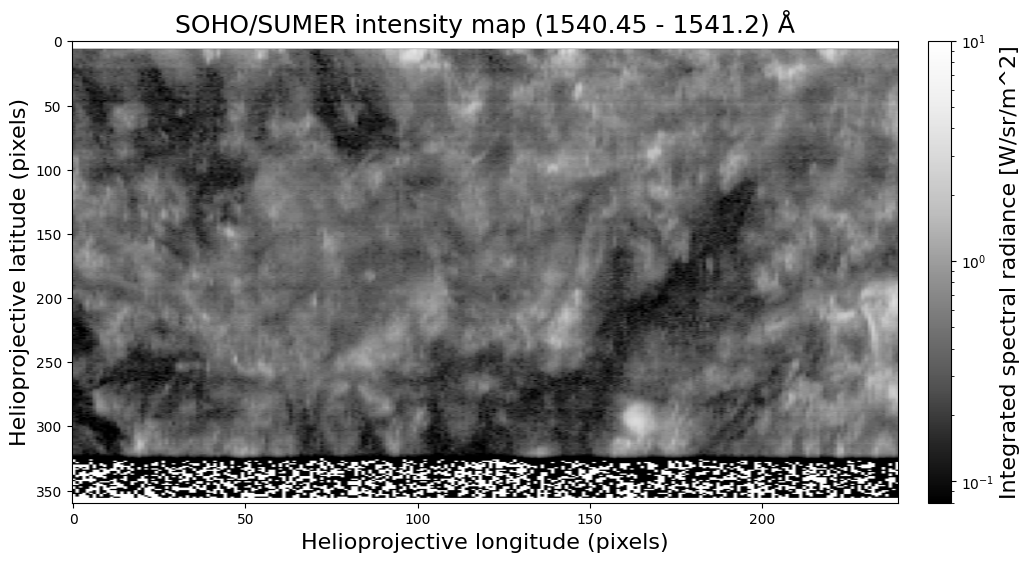

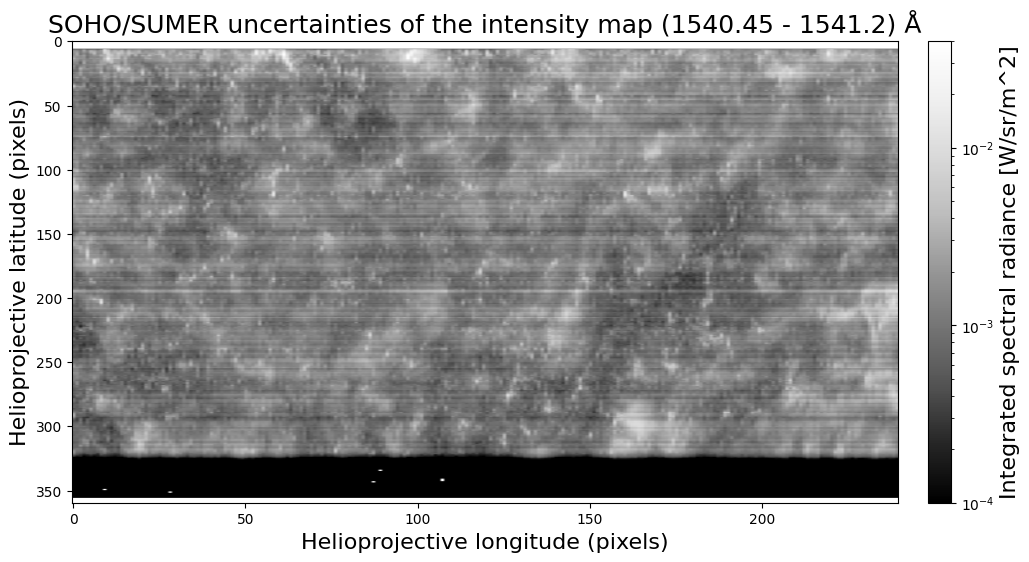

In [9]:
#Show intensity map
N_lat, N_lon = intensity_map.shape
x_edges = np.arange(0-0.5, N_lon-1+0.5)   # length Nx+1
y_edges = np.arange(0-0.5, N_lat-1+0.5)[::-1]  # length Ny+1


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 6))
img = ax.imshow(intensity_map, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), aspect='auto')
cbar = fig.colorbar(img, ax=ax, pad=0.03)
cbar.set_label(f'Integrated spectral radiance [W/sr/m^2]', fontsize=16)
ax.set_title(f'SOHO/SUMER intensity map ({round(wavelength_range_intensity_map[0],2)} - {round(wavelength_range_intensity_map[1],2)}) \u212B', fontsize=18)
ax.set_xlabel('Helioprojective longitude (pixels)', fontsize=16)
ax.set_ylabel('Helioprojective latitude (pixels)', fontsize=16)
ax.axis('auto') # Ensures equal scaling of axis x and y
plt.show(block=False)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 6))
img = ax.imshow(intensity_map_unc, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer_unc, vmax=vmax_sumer_unc), aspect='auto')
cbar = fig.colorbar(img, ax=ax, pad=0.03)
cbar.set_label(f'Integrated spectral radiance [W/sr/m^2]', fontsize=16)
ax.set_title(f'SOHO/SUMER uncertainties of the intensity map ({round(wavelength_range_intensity_map[0],2)} - {round(wavelength_range_intensity_map[1],2)}) \u212B', fontsize=18)
ax.set_xlabel('Helioprojective longitude (pixels)', fontsize=16)
ax.set_ylabel('Helioprojective latitude (pixels)', fontsize=16)
ax.axis('auto') # Ensures equal scaling of axis x and y
plt.show(block=False)

In [10]:
# Save intensity map and uncertainties as .npy
if save_intensity_map == 'yes':
    filename_profile = 'intensity_map_'+line_label+'_interpolated___.npz'
    foldepath_profile = '../auxiliar_functions/'
    np.savez(foldepath_profile+filename_profile, intensity_map=intensity_map, intensity_map_unc=intensity_map_unc, line_center_label=line_center_label, vmin_vmax=[vmin_sumer, vmax_sumer])


"""
In order to load the intensity map in another file (or this one), do the next:

intensitymap_loaded_dic = np.load('intensity_map_'+line_label+'_interpolated___.npz')
intensity_map = intensitymap_loaded_dic['intensity_map'] #[W/sr/m^2] 2D-array
intensity_map_unc = intensitymap_loaded_dic['intensity_map_unc'] #[W/sr/m^2] 2D-array
line_center_label = intensitymap_loaded_dic['line_center_label'] 
vmin_sumer, vmax_sumer = intensitymap_loaded_dic['vmin_vmax'] 

"""
""

''